In [1]:
import numpy as np
import pandas as pd
import cantera as ct
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
CARLY_YAML = "john_priori_sub_opt.yaml"
CARLY_PCT  = 0.10   # +/- fractional band on Carly's own H2O/OH mole-fraction profile

CONDITIONS = {
    "1192 K": dict(T=1205.347, P_atm=1.947, xH2O2=2220e-6, xH2O=1360e-6, xO2=680e-6,
                   oh_csv="hong_1192K_oh.csv", h2o_csv="hong_1192K_h2o.csv"),
    "1398 K": dict(T=1409.661, P_atm=1.900, xH2O2=2550e-6, xH2O=1240e-6, xO2=617e-6,
                   oh_csv="hong_1398K_oh.csv", h2o_csv="hong_1398K_h2o.csv"),
}

# Same two-grid convention as optimize_joint_generic_comp.py: a coarse grid out to
# 1 ms for the slower H2O rise, and a finer front-loaded grid for the fast OH spike.
DT_SIM, N_STEPS = 1e-6, 1000
T_SIM = np.linspace(DT_SIM, DT_SIM * N_STEPS, N_STEPS)
T_OH  = np.concatenate([np.linspace(1e-7, 2e-4, 600), np.linspace(2e-4 + 5e-6, 1e-3, 200)])

In [7]:
def run_carly_profiles(T_initial, P_atm, xH2O2, xH2O, xO2):
    """Integrate Carly's mechanism at its own nominal rates; return H2O on T_SIM, OH on T_OH."""
    gas = ct.Solution(CARLY_YAML)
    P_initial = P_atm * ct.one_atm
    X = {'H2O2': xH2O2, 'H2O': xH2O, 'O2': xO2, 'AR': 1.0 - (xH2O2 + xH2O + xO2)}
    gas.TPX = T_initial, P_initial, X
    rr  = ct.IdealGasConstPressureReactor(gas, energy="on")
    net = ct.ReactorNet([rr])
    hi, oi = gas.species_index("H2O"), gas.species_index("OH")
    allt  = np.concatenate([T_SIM, T_OH])
    order = np.argsort(allt, kind="stable")
    hv, ov = np.empty(len(allt)), np.empty(len(allt))
    for k, t in enumerate(allt[order]):
        net.advance(t)
        hv[order[k]] = rr.thermo.X[hi]
        ov[order[k]] = rr.thermo.X[oi]
    return hv[:N_STEPS], ov[N_STEPS:]

In [8]:
results = {}
for label, c in CONDITIONS.items():
    print(f"Running Carly model @ {label} ...")
    h2o, oh = run_carly_profiles(c["T"], c["P_atm"], c["xH2O2"], c["xH2O"], c["xO2"])

    df_h2o = pd.read_csv(c["h2o_csv"], skipinitialspace=True)
    df_oh  = pd.read_csv(c["oh_csv"],  skipinitialspace=True)
    h2o_agg = df_h2o.groupby("Time [ms]")["[H2O] ppm"].mean().reset_index()
    oh_agg  = df_oh.groupby("Time [ms]")["[OH] ppm"].mean().reset_index()

    results[label] = dict(h2o=h2o, oh=oh, df_h2o=df_h2o, df_oh=df_oh,
                           h2o_agg=h2o_agg, oh_agg=oh_agg)
print("Done.")

Running Carly model @ 1192 K ...
Running Carly model @ 1398 K ...
Done.


/tmp/ipykernel_91097/2746865286.py:7: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  rr  = ct.IdealGasConstPressureReactor(gas, energy="on")
/tmp/ipykernel_91097/2746865286.py:15: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  hv[order[k]] = rr.thermo.X[hi]
/tmp/ipykernel_91097/2746865286.py:16: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  ov[order[k]] = rr.thermo.X[oi]


Saved fig_carly_priori_updated_1192k.png


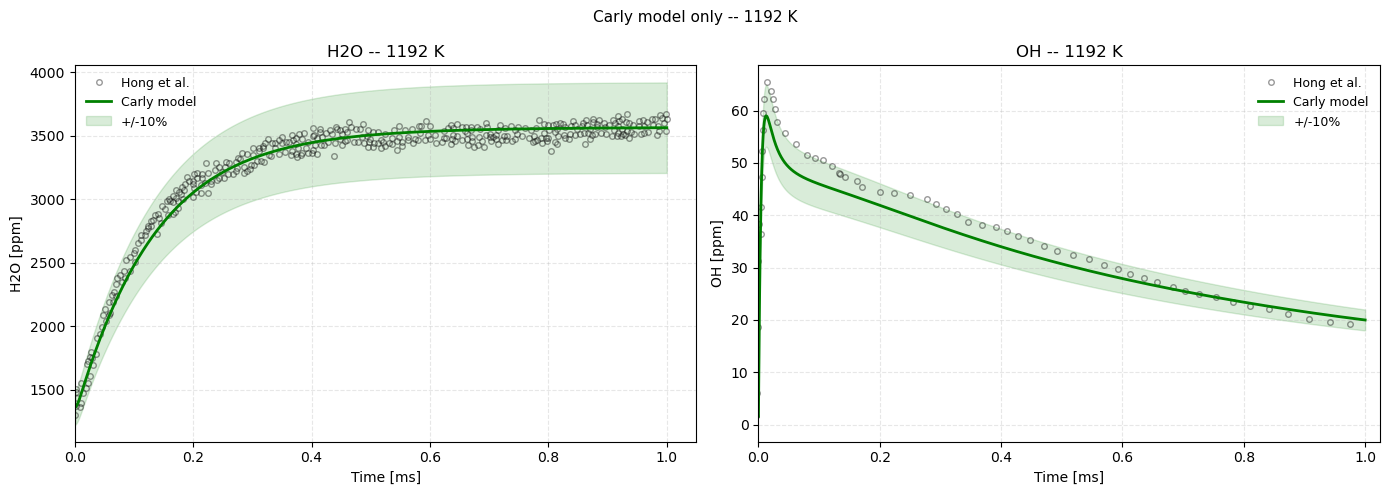

Saved fig_carly_priori_updated_1398k.png


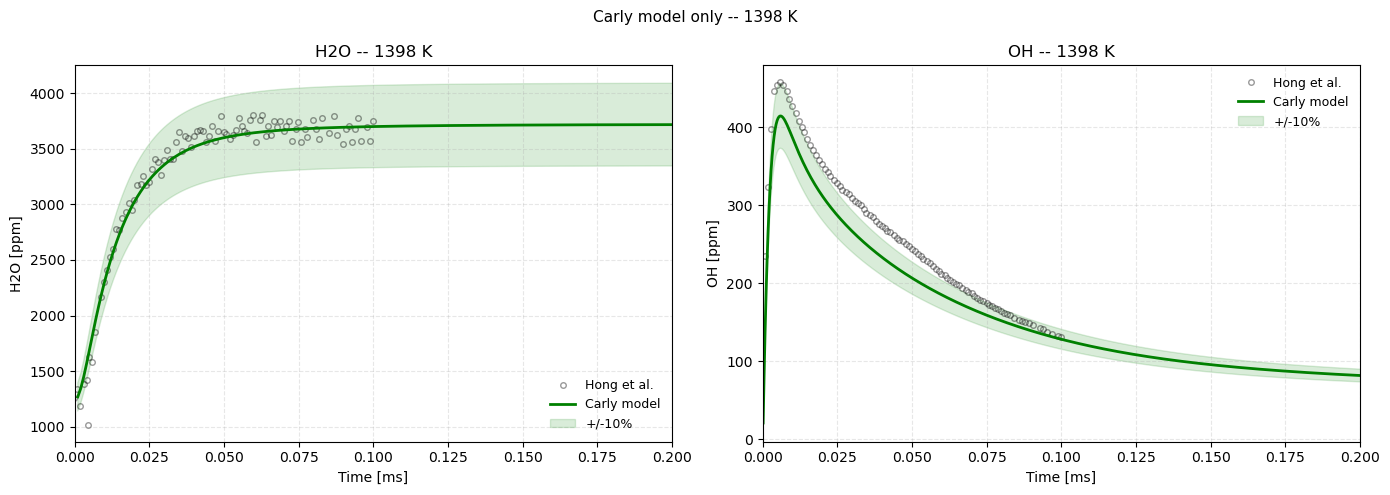

In [9]:
XLIM_FLOOR_MS = {"1398 K": 0.2}  # extend 1398 K view past its ~0.1 ms data range

for label, r in results.items():
    h2o, oh = r["h2o"], r["oh"]
    h2o_up, h2o_dn = h2o * (1 + CARLY_PCT), h2o * (1 - CARLY_PCT)
    oh_up,  oh_dn  = oh  * (1 + CARLY_PCT), oh  * (1 - CARLY_PCT)
    xlim_floor = XLIM_FLOOR_MS.get(label, 0.06)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(r["df_h2o"]["Time [ms]"], r["df_h2o"]["[H2O] ppm"], "o",
             mfc="none", mec="k", ms=4, alpha=0.4, label="Hong et al.")
    ax1.plot(T_SIM * 1e3, h2o * 1e6, "g-", lw=2.0, label="Carly model")
    ax1.fill_between(T_SIM * 1e3, h2o_dn * 1e6, h2o_up * 1e6,
                      color="green", alpha=0.15, label=f"+/-{CARLY_PCT*100:.0f}%")
    ax1.set(xlabel="Time [ms]", ylabel="H2O [ppm]",
            xlim=[0, max(r['df_h2o']['Time [ms]'].max() * 1.05, xlim_floor)],
            title=f"H2O -- {label}")
    ax1.legend(frameon=False, fontsize=9); ax1.grid(True, ls="--", alpha=0.3)

    ax2.plot(r["df_oh"]["Time [ms]"], r["df_oh"]["[OH] ppm"], "o",
             mfc="none", mec="k", ms=4, alpha=0.4, label="Hong et al.")
    ax2.plot(T_OH * 1e3, oh * 1e6, "g-", lw=2.0, label="Carly model")
    ax2.fill_between(T_OH * 1e3, oh_dn * 1e6, oh_up * 1e6,
                      color="green", alpha=0.15, label=f"+/-{CARLY_PCT*100:.0f}%")
    ax2.set(xlabel="Time [ms]", ylabel="OH [ppm]",
            xlim=[0, max(r['df_oh']['Time [ms]'].max() * 1.05, xlim_floor)],
            title=f"OH -- {label}")
    ax2.legend(frameon=False, fontsize=9); ax2.grid(True, ls="--", alpha=0.3)

    fig.suptitle(f"Carly model only -- {label}", fontsize=11)
    plt.tight_layout()
    out = f"fig_carly_priori_updated_{label.replace(' ', '').replace('K','k')}.png"
    plt.savefig(out, dpi=110, bbox_inches="tight")
    print(f"Saved {out}")
    plt.show()